# VoiceBank Speech Enhancement: Evaluation Metrics & Model Testing

**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.


**Notebook Overview**:
Complete training system with evaluation metrics and monitoring
- Load the dataset (train/val split)
- Initialize the DataLoader
- Define the UNet model
- Set the optimizer & loss function
- Train for a few epochs with progress logging
- Save the model weights


**Next Steps**:
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
import torch
import torch.nn as nn
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import pearsonr
import os
from tqdm import tqdm
import soundfile as sf
from IPython.display import Audio, display
import pandas as pd
from collections import defaultdict
import json

In [2]:
import sys

sys.path.append("/kaggle/usr/lib/models")
sys.path.append("/kaggle/usr/lib/dataset_class")
from models import UNet, create_model
from dataset_class import create_dataloaders, VoiceBankDataset

In [3]:
try:
    import pesq
    PESQ_AVAILABLE = True
except ImportError:
    PESQ_AVAILABLE = False
    print("⚠️ PESQ not available. Install with: pip install pesq")

try:
    import pystoi
    STOI_AVAILABLE = True  
except ImportError:
    STOI_AVAILABLE = False
    print("⚠️ STOI not available. Install with: pip install pystoi")

⚠️ PESQ not available. Install with: pip install pesq
⚠️ STOI not available. Install with: pip install pystoi


In [4]:
pip install pesq

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp311-cp311-linux_x86_64.whl size=275940 sha256=ab1dfc4a6c0fda705a60e9a63c354fa1b529cec621b9e0aa493b6b5d8a573e73
  Stored in directory: /root/.cache/pip/wheels/ae/f1/23/2698d0bf31eec2b2aa50623b5d93b6206c49c7155d0e31345d
Successfully built pesq
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pystoi

Note: you may need to restart the kernel to use updated packages.


In [6]:
class ComprehensiveEvaluator:
    """Comprehensive evaluation metrics for speech enhancement"""
    
    def __init__(self, sample_rate=16000):
        self.sample_rate = sample_rate
        
    def calculate_snr(self, clean, enhanced, eps=1e-10):
        """Calculate Signal-to-Noise Ratio"""
        signal_power = np.mean(clean ** 2)
        noise_power = np.mean((clean - enhanced) ** 2)
        snr = 10 * np.log10(signal_power / (noise_power + eps))
        return snr
    
    def calculate_sdr(self, clean, enhanced, eps=1e-10):
        """Calculate Signal-to-Distortion Ratio"""
        # Similar to SNR but focuses on distortion
        return self.calculate_snr(clean, enhanced, eps)
    
    def calculate_pesq(self, clean, enhanced):
        """Calculate PESQ score"""
        if not PESQ_AVAILABLE:
            return None
        
        try:
            # Ensure signals are the same length
            min_len = min(len(clean), len(enhanced))
            clean = clean[:min_len]
            enhanced = enhanced[:min_len]
            
            # PESQ expects signals in range [-1, 1] and at 16kHz
            pesq_score = pesq.pesq(self.sample_rate, clean, enhanced, 'wb')
            return pesq_score
        except Exception as e:
            print(f"PESQ calculation failed: {e}")
            return None
    
    def calculate_stoi(self, clean, enhanced):
        """Calculate Short-Time Objective Intelligibility"""
        if not STOI_AVAILABLE:
            return None
        
        try:
            min_len = min(len(clean), len(enhanced))
            clean = clean[:min_len]
            enhanced = enhanced[:min_len]
            
            stoi_score = pystoi.stoi(clean, enhanced, self.sample_rate, extended=False)
            return stoi_score
        except Exception as e:
            print(f"STOI calculation failed: {e}")
            return None
    
    def calculate_lsd(self, clean, enhanced):
        """Calculate Log-Spectral Distance"""
        # Compute spectrograms
        S_clean = np.abs(librosa.stft(clean, n_fft=512, hop_length=128))
        S_enhanced = np.abs(librosa.stft(enhanced, n_fft=512, hop_length=128))
        
        # Convert to log scale
        log_S_clean = np.log(S_clean + 1e-10)
        log_S_enhanced = np.log(S_enhanced + 1e-10)
        
        # Calculate LSD
        lsd = np.mean((log_S_clean - log_S_enhanced) ** 2) ** 0.5
        return lsd
    
    def calculate_spectral_convergence(self, clean, enhanced):
        """Calculate spectral convergence"""
        S_clean = np.abs(librosa.stft(clean))
        S_enhanced = np.abs(librosa.stft(enhanced))
        
        numerator = np.linalg.norm(S_clean - S_enhanced, 'fro')
        denominator = np.linalg.norm(S_clean, 'fro')
        
        return numerator / denominator
    
    def calculate_all_metrics(self, clean, enhanced):
        """Calculate all available metrics"""
        metrics = {}
        
        # Basic metrics
        metrics['snr'] = self.calculate_snr(clean, enhanced)
        metrics['sdr'] = self.calculate_sdr(clean, enhanced)
        metrics['lsd'] = self.calculate_lsd(clean, enhanced)
        metrics['spectral_convergence'] = self.calculate_spectral_convergence(clean, enhanced)
        
        # Correlation
        if len(clean) > 1 and len(enhanced) > 1:
            correlation, _ = pearsonr(clean, enhanced)
            metrics['correlation'] = correlation
        else:
            metrics['correlation'] = 0.0
        
        # Perceptual metrics
        metrics['pesq'] = self.calculate_pesq(clean, enhanced)
        metrics['stoi'] = self.calculate_stoi(clean, enhanced)
        
        return metrics

In [7]:
def evaluate_model_on_dataset(model, dataloader, evaluator, device, 
                            feature_type='logmel', max_samples=None):
    """Evaluate model on entire dataset"""
    
    model.eval()
    all_metrics = defaultdict(list)
    sample_count = 0
    
    print(f"🧪 Evaluating model on {len(dataloader)} batches...")
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_samples and sample_count >= max_samples:
                break
                
            noisy, clean = noisy.to(device), clean.to(device)
            
            # Model prediction
            enhanced = model(noisy)
            
            # Process each sample in batch
            batch_size = noisy.shape[0]
            for i in range(batch_size):
                if max_samples and sample_count >= max_samples:
                    break
                
                # Convert spectrograms back to waveforms for perceptual metrics
                clean_spec = clean[i].squeeze().cpu().numpy()
                enhanced_spec = enhanced[i].squeeze().cpu().numpy()
                
                # Convert from dB back to magnitude if needed
                if feature_type == 'logmel':
                    # For log-mel, we need to convert back to waveform
                    # This is an approximation using Griffin-Lim
                    clean_wave = librosa.feature.inverse.mel_to_audio(
                        librosa.db_to_power(clean_spec), 
                        sr=evaluator.sample_rate, 
                        n_fft=512, 
                        hop_length=128
                    )
                    enhanced_wave = librosa.feature.inverse.mel_to_audio(
                        librosa.db_to_power(enhanced_spec), 
                        sr=evaluator.sample_rate, 
                        n_fft=512, 
                        hop_length=128
                    )
                else:
                    # For STFT, use Griffin-Lim algorithm
                    clean_wave = librosa.griffinlim(
                        librosa.db_to_amplitude(clean_spec),
                        hop_length=128,
                        n_iter=32
                    )
                    enhanced_wave = librosa.griffinlim(
                        librosa.db_to_amplitude(enhanced_spec),
                        hop_length=128,
                        n_iter=32
                    )
                
                # Calculate metrics
                try:
                    metrics = evaluator.calculate_all_metrics(clean_wave, enhanced_wave)
                    
                    for key, value in metrics.items():
                        if value is not None and not np.isnan(value):
                            all_metrics[key].append(value)
                
                except Exception as e:
                    print(f"Error calculating metrics for sample {sample_count}: {e}")
                    continue
                
                sample_count += 1
    
    # Calculate summary statistics
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics

In [8]:
def create_evaluation_report(metrics_summary, model_name, dataset_name):
    """Create a comprehensive evaluation report"""
    
    print(f"\n📊 Evaluation Report: {model_name} on {dataset_name}")
    print("=" * 80)
    
    # Table of results
    df_data = []
    for metric_name, stats in metrics_summary.items():
        df_data.append({
            'Metric': metric_name.upper(),
            'Mean': f"{stats['mean']:.4f}",
            'Std': f"{stats['std']:.4f}",
            'Median': f"{stats['median']:.4f}",
            'Min': f"{stats['min']:.4f}",
            'Max': f"{stats['max']:.4f}",
            'Samples': stats['count']
        })
    
    df = pd.DataFrame(df_data)
    print(df.to_string(index=False))
    
    # Interpretation
    print(f"\n💡 Interpretation:")
    
    if 'snr' in metrics_summary:
        snr_mean = metrics_summary['snr']['mean']
        if snr_mean > 15:
            snr_quality = "Excellent"
        elif snr_mean > 10:
            snr_quality = "Good"
        elif snr_mean > 5:
            snr_quality = "Fair"
        else:
            snr_quality = "Poor"
        print(f"   SNR: {snr_mean:.2f} dB ({snr_quality} enhancement)")
    
    if 'pesq' in metrics_summary and metrics_summary['pesq']['count'] > 0:
        pesq_mean = metrics_summary['pesq']['mean']
        if pesq_mean > 3.5:
            pesq_quality = "Excellent"
        elif pesq_mean > 2.5:
            pesq_quality = "Good"
        elif pesq_mean > 1.5:
            pesq_quality = "Fair"
        else:
            pesq_quality = "Poor"
        print(f"   PESQ: {pesq_mean:.3f} ({pesq_quality} perceptual quality)")
    
    if 'stoi' in metrics_summary and metrics_summary['stoi']['count'] > 0:
        stoi_mean = metrics_summary['stoi']['mean']
        if stoi_mean > 0.9:
            stoi_quality = "Excellent"
        elif stoi_mean > 0.8:
            stoi_quality = "Good"
        elif stoi_mean > 0.7:
            stoi_quality = "Fair"
        else:
            stoi_quality = "Poor"
        print(f"   STOI: {stoi_mean:.3f} ({stoi_quality} intelligibility)")
    
    return df

In [9]:
def plot_metrics_distribution(all_metrics, save_path=None):
    """Plot distribution of evaluation metrics"""
    
    # Filter out metrics with data
    metrics_to_plot = {k: v for k, v in all_metrics.items() 
                      if v and len(v) > 10}
    
    if not metrics_to_plot:
        print("No metrics data to plot")
        return
    
    n_metrics = len(metrics_to_plot)
    cols = min(3, n_metrics)
    rows = (n_metrics + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_metrics == 1:
        axes = [axes]
    elif rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (metric_name, values) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Histogram
        ax.hist(values, bins=30, alpha=0.7, edgecolor='black')
        ax.set_title(f'{metric_name.upper()} Distribution')
        ax.set_xlabel(f'{metric_name.upper()} Value')
        ax.set_ylabel('Frequency')
        
        # Add statistics
        mean_val = np.mean(values)
        std_val = np.std(values)
        ax.axvline(mean_val, color='red', linestyle='--', 
                  label=f'Mean: {mean_val:.3f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', 
                  alpha=0.7, label=f'+1σ: {mean_val + std_val:.3f}')
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', 
                  alpha=0.7, label=f'-1σ: {mean_val - std_val:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
def compare_models(model_results, dataset_name):
    """Compare multiple models side by side"""
    
    print(f"\n🏆 Model Comparison on {dataset_name}")
    print("=" * 100)
    
    # Get all metrics that appear in any model
    all_metric_names = set()
    for model_name, results in model_results.items():
        all_metric_names.update(results.keys())
    
    all_metric_names = sorted(all_metric_names)
    
    # Create comparison table
    comparison_data = []
    for metric_name in all_metric_names:
        row = {'Metric': metric_name.upper()}
        
        for model_name, results in model_results.items():
            if metric_name in results:
                mean_val = results[metric_name]['mean']
                std_val = results[metric_name]['std']
                row[model_name] = f"{mean_val:.4f} ± {std_val:.4f}"
            else:
                row[model_name] = "N/A"
        
        comparison_data.append(row)
    
    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    
    # Identify best performing model for each metric
    print(f"\n🥇 Best Performing Models:")
    for metric_name in all_metric_names:
        best_model = None
        best_score = float('-inf') if metric_name in ['snr', 'pesq', 'stoi', 'correlation'] else float('inf')
        
        for model_name, results in model_results.items():
            if metric_name in results:
                score = results[metric_name]['mean']
                
                if metric_name in ['snr', 'pesq', 'stoi', 'correlation']:
                    # Higher is better
                    if score > best_score:
                        best_score = score
                        best_model = model_name
                else:
                    # Lower is better (LSD, spectral_convergence)
                    if score < best_score:
                        best_score = score
                        best_model = model_name
        
        if best_model:
            print(f"   {metric_name.upper()}: {best_model} ({best_score:.4f})")
    return df_comparison

In [11]:
def visualize_spectrograms_comparison(model, dataloader, device, num_samples=3, 
                                    feature_type='logmel', save_path=None):
    """Visualize input, target, and enhanced spectrograms"""
    
    model.eval()
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(dataloader):
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            # Take first few samples from batch
            batch_size = min(num_samples, noisy.shape[0])
            
            fig, axes = plt.subplots(batch_size, 3, figsize=(15, 5*batch_size))
            if batch_size == 1:
                axes = axes.reshape(1, -1)
            
            for i in range(batch_size):
                # Convert to numpy and remove channel dimension
                noisy_spec = noisy[i].squeeze().cpu().numpy()
                clean_spec = clean[i].squeeze().cpu().numpy()
                enhanced_spec = enhanced[i].squeeze().cpu().numpy()
                
                # Plot noisy
                im1 = axes[i, 0].imshow(noisy_spec, aspect='auto', origin='lower', 
                                      cmap='viridis')
                axes[i, 0].set_title(f'Noisy Input {i+1}')
                axes[i, 0].set_xlabel('Time Frames')
                if feature_type == 'logmel':
                    axes[i, 0].set_ylabel('Mel Bins')
                else:
                    axes[i, 0].set_ylabel('Frequency Bins')
                plt.colorbar(im1, ax=axes[i, 0], shrink=0.8)
                
                # Plot clean target
                im2 = axes[i, 1].imshow(clean_spec, aspect='auto', origin='lower', 
                                      cmap='viridis')
                axes[i, 1].set_title(f'Clean Target {i+1}')
                axes[i, 1].set_xlabel('Time Frames')
                if feature_type == 'logmel':
                    axes[i, 1].set_ylabel('Mel Bins')
                else:
                    axes[i, 1].set_ylabel('Frequency Bins')
                plt.colorbar(im2, ax=axes[i, 1], shrink=0.8)
                
                # Plot enhanced output
                im3 = axes[i, 2].imshow(enhanced_spec, aspect='auto', origin='lower', 
                                      cmap='viridis')
                axes[i, 2].set_title(f'Enhanced Output {i+1}')
                axes[i, 2].set_xlabel('Time Frames')
                if feature_type == 'logmel':
                    axes[i, 2].set_ylabel('Mel Bins')
                else:
                    axes[i, 2].set_ylabel('Frequency Bins')
                plt.colorbar(im3, ax=axes[i, 2], shrink=0.8)
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.show()
            
            # Only show first batch
            break

In [12]:
import numpy as np
import librosa
import torch

def reconstruct_audio_from_logmel(logmel_db, sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Properly reconstruct audio from log-mel spectrogram
    
    Args:
        logmel_db: Log-mel spectrogram in dB scale, shape (n_mels, time)
        sr: Sample rate
        n_fft: FFT size
        hop_length: Hop length
        n_mels: Number of mel bands
        
    Returns:
        audio: Reconstructed audio waveform
    """
    
    # Step 1: Convert from dB to power
    mel_power = librosa.db_to_power(logmel_db)
    
    # Step 2: Invert mel filterbank to get approximate STFT magnitude
    # Create mel basis
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    
    # Pseudo-inverse to go from mel to STFT
    mel_basis_inv = np.linalg.pinv(mel_basis)
    stft_magnitude = np.dot(mel_basis_inv, mel_power)
    
    # Ensure non-negative
    stft_magnitude = np.maximum(stft_magnitude, 0)
    
    # Step 3: Use Griffin-Lim to reconstruct phase and audio
    audio = librosa.griffinlim(
        stft_magnitude,
        hop_length=hop_length,
        n_iter=32,  # More iterations = better quality
        length=None
    )
    
    return audio


def reconstruct_audio_batch(logmel_batch_db, sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Reconstruct audio from a batch of log-mel spectrograms
    
    Args:
        logmel_batch_db: Batch of log-mel specs, shape (batch, 1, n_mels, time) or (batch, n_mels, time)
        
    Returns:
        List of audio waveforms
    """
    # Handle different input shapes
    if isinstance(logmel_batch_db, torch.Tensor):
        logmel_batch_db = logmel_batch_db.cpu().numpy()
    
    # Remove channel dimension if present
    if logmel_batch_db.ndim == 4:
        logmel_batch_db = logmel_batch_db.squeeze(1)
    
    audios = []
    for i in range(logmel_batch_db.shape[0]):
        audio = reconstruct_audio_from_logmel(
            logmel_batch_db[i],
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        audios.append(audio)
    
    return audios


# Alternative: Direct approach without mel inversion (faster but less accurate)
def reconstruct_audio_simple(logmel_db, sr=16000, hop_length=128):
    """
    Simpler reconstruction using mel_to_audio directly
    Note: This treats the log-mel as if it were linear, which is not ideal
    but can work for relative comparisons
    """
    # Convert dB to power
    mel_power = librosa.db_to_power(logmel_db)
    
    # Direct synthesis (treats it as harmonic content)
    audio = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=sr,
        hop_length=hop_length,
        n_fft=512
    )
    
    return audio

In [13]:
def generate_audio_samples_fixed(model, dataloader, device, output_dir='audio_samples',
                                 num_samples=3, feature_type='logmel',
                                 sample_rate=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Generate audio samples with FIXED reconstruction
    """
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    print(f"🔊 Generating {num_samples} audio samples...")
    
    # Create mel basis for reconstruction
    mel_basis = librosa.filters.mel(sr=sample_rate, n_fft=n_fft, n_mels=n_mels, fmax=sample_rate//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    
    sample_count = 0
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(dataloader):
            if sample_count >= num_samples:
                break
            
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            batch_size = noisy.shape[0]
            
            for i in range(batch_size):
                if sample_count >= num_samples:
                    break
                
                # Get spectrograms
                noisy_spec = noisy[i].squeeze().cpu().numpy()
                clean_spec = clean[i].squeeze().cpu().numpy()
                enhanced_spec = enhanced[i].squeeze().cpu().numpy()
                
                try:
                    # PROPER RECONSTRUCTION
                    # Convert from dB to power
                    noisy_power = librosa.db_to_power(noisy_spec)
                    clean_power = librosa.db_to_power(clean_spec)
                    enhanced_power = librosa.db_to_power(enhanced_spec)
                    
                    # Invert mel filterbank
                    noisy_stft = np.maximum(np.dot(mel_basis_inv, noisy_power), 0)
                    clean_stft = np.maximum(np.dot(mel_basis_inv, clean_power), 0)
                    enhanced_stft = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
                    
                    # Griffin-Lim reconstruction
                    noisy_audio = librosa.griffinlim(noisy_stft, hop_length=hop_length, n_iter=32)
                    clean_audio = librosa.griffinlim(clean_stft, hop_length=hop_length, n_iter=32)
                    enhanced_audio = librosa.griffinlim(enhanced_stft, hop_length=hop_length, n_iter=32)
                    
                    # Ensure same length
                    min_len = min(len(noisy_audio), len(clean_audio), len(enhanced_audio))
                    noisy_audio = noisy_audio[:min_len]
                    clean_audio = clean_audio[:min_len]
                    enhanced_audio = enhanced_audio[:min_len]
                    
                    # Normalize
                    noisy_audio = noisy_audio / (np.max(np.abs(noisy_audio)) + 1e-8)
                    clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
                    enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
                    
                    # Save audio files
                    sample_id = f"sample_{sample_count:03d}"
                    sf.write(f"{output_dir}/{sample_id}_noisy.wav", noisy_audio, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_clean.wav", clean_audio, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_enhanced.wav", enhanced_audio, sample_rate)
                    
                    sample_count += 1
                    
                except Exception as e:
                    print(f"⚠️  Error generating sample {sample_count}: {e}")
                    continue
    
    print(f"✅ Generated {sample_count} audio samples in {output_dir}/")
    return output_dir

In [14]:
def generate_audio_samples(model, dataloader, device, output_dir='audio_samples', 
                         num_samples=3, feature_type='logmel', sample_rate=16000):
    """Generate audio samples for listening tests"""
    
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    print(f"🎵 Generating {num_samples} audio samples...")
    
    sample_count = 0
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(dataloader):
            if sample_count >= num_samples:
                break
                
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            batch_size = noisy.shape[0]
            
            for i in range(batch_size):
                if sample_count >= num_samples:
                    break
                
                # Convert spectrograms to numpy
                noisy_spec = noisy[i].squeeze().cpu().numpy()
                clean_spec = clean[i].squeeze().cpu().numpy()
                enhanced_spec = enhanced[i].squeeze().cpu().numpy()
                
                # Convert back to audio (approximation)
                if feature_type == 'logmel':
                    # Convert log-mel back to audio
                    noisy_audio = reconstruct_audio_from_logmel(noisy_logmel)
                    clean_audio = reconstruct_audio_from_logmel(clean_logmel)
                    enhanced_audio = reconstruct_audio_from_logmel(enhanced_logmel)
                else:
                    # Use Griffin-Lim for STFT
                    noisy_audio = librosa.griffinlim(librosa.db_to_amplitude(noisy_spec))
                    clean_audio = librosa.griffinlim(librosa.db_to_amplitude(clean_spec))
                    enhanced_audio = librosa.griffinlim(librosa.db_to_amplitude(enhanced_spec))
                
                # Normalize audio
                noisy_audio = noisy_audio / np.max(np.abs(noisy_audio))
                clean_audio = clean_audio / np.max(np.abs(clean_audio))
                enhanced_audio = enhanced_audio / np.max(np.abs(enhanced_audio))
                
                # Save audio files
                sample_id = f"sample_{sample_count:03d}"
                
                sf.write(f"{output_dir}/{sample_id}_noisy.wav", 
                        noisy_audio, sample_rate)
                sf.write(f"{output_dir}/{sample_id}_clean.wav", 
                        clean_audio, sample_rate)
                sf.write(f"{output_dir}/{sample_id}_enhanced.wav", 
                        enhanced_audio, sample_rate)
                
                sample_count += 1
    
    print(f"✅ Generated {sample_count} audio samples in {output_dir}/")
    return output_dir

In [15]:
def create_listening_test_interface(audio_dir, num_samples=5):
    """Create an interactive listening test interface for Jupyter"""
    
    print("🎧 Interactive Listening Test")
    print("=" * 50)
    
    for i in range(num_samples):
        sample_id = f"sample_{i:03d}"
        
        noisy_path = f"{audio_dir}/{sample_id}_noisy.wav"
        clean_path = f"{audio_dir}/{sample_id}_clean.wav"
        enhanced_path = f"{audio_dir}/{sample_id}_enhanced.wav"
        
        if all(os.path.exists(path) for path in [noisy_path, clean_path, enhanced_path]):
            print(f"\n🔊 Sample {i+1}:")
            print("   Noisy Input:")
            display(Audio(noisy_path))
            
            print("   Clean Target:")
            display(Audio(clean_path))
            
            print("   Enhanced Output:")
            display(Audio(enhanced_path))
            
            print("   " + "-"*40)

In [16]:

# may delete this later

def run_comprehensive_evaluation(model, test_loader, device, model_name, 
                               feature_type='logmel', max_samples=500):
    """Run complete evaluation pipeline"""
    
    print(f"🚀 Running comprehensive evaluation for {model_name}")
    
    # Initialize evaluator
    evaluator = ComprehensiveEvaluator()
    
    # Evaluate model
    print("📊 Calculating metrics...")
    metrics_summary, all_metrics = evaluate_model_on_dataset(
        model, test_loader, evaluator, device, 
        feature_type=feature_type, max_samples=max_samples
    )
    
    # Create report
    print("📝 Creating evaluation report...")
    report_df = create_evaluation_report(metrics_summary, model_name, "Test Set")
    
    # Plot distributions
    print("📈 Plotting metric distributions...")
    plot_metrics_distribution(all_metrics, 
                            save_path=f'metrics_distribution_{model_name}.png')
    
    # Visualize spectrograms
    print("🎨 Visualizing spectrograms...")
    visualize_spectrograms_comparison(model, test_loader, device, 
                                    num_samples=3, feature_type=feature_type,
                                    save_path=f'spectrograms_{model_name}.png')
    
    # Generate audio samples
    print("🎵 Generating audio samples...")
    audio_dir = generate_audio_samples(model, test_loader, device, 
                                     output_dir=f'audio_samples_{model_name}',
                                     num_samples=3, feature_type=feature_type)
    
    # Create listening test
    print("🎧 Creating listening test...")
    create_listening_test_interface(audio_dir, num_samples=3)
    
    return metrics_summary, all_metrics, report_df

In [17]:
import numpy as np
import librosa
import soundfile as sf
import torch
import os
from tqdm import tqdm

def denormalize_spectrogram(normalized_spec, stats, split='clean'):
    """
    Denormalize spectrogram back to dB scale
    
    Args:
        normalized_spec: Normalized spectrogram (mean~0, std~1)
        stats: Dictionary with normalization statistics
        split: 'clean' or 'noisy'
    
    Returns:
        Spectrogram in dB scale
    """
    mean = stats[f'{split}_mean']
    std = stats[f'{split}_std']
    
    # Reverse the normalization: x_original = x_normalized * std + mean
    denormalized = normalized_spec * std + mean
    
    return denormalized


def load_normalization_stats(feature_dir='/kaggle/input/voicebank-features/voicebank_features', 
                             feature_type='logmel'):
    """
    Load the normalization statistics used during training
    """
    import pickle
    
    # Try to load from the same location used in dataset_class
    stats_file = "/kaggle/input/normalisation-stats/logmel/norm_stats_logmel.pkl"
    
    if not os.path.exists(stats_file):
        # Fallback: try alternative location
        stats_file = os.path.join(feature_type, f'norm_stats_{feature_type}.pkl')
    
    if os.path.exists(stats_file):
        with open(stats_file, 'rb') as f:
            stats = pickle.load(f)
        print(f"✅ Loaded normalization stats from {stats_file}")
        print(f"   Noisy: μ={stats['noisy_mean']:.3f}, σ={stats['noisy_std']:.3f}")
        print(f"   Clean: μ={stats['clean_mean']:.3f}, σ={stats['clean_std']:.3f}")
        return stats
    else:
        raise FileNotFoundError(f"Cannot find normalization stats at {stats_file}")


def reconstruct_audio_from_normalized_logmel(normalized_logmel, stats, split='clean',
                                             sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Reconstruct audio from NORMALIZED log-mel spectrogram
    
    This is the KEY function that was missing!
    """
    # Step 1: DENORMALIZE to get back to dB scale
    logmel_db = denormalize_spectrogram(normalized_logmel, stats, split)
    
    # Step 2: Convert from dB to power
    mel_power = librosa.db_to_power(logmel_db)
    
    # Step 3: Invert mel filterbank
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    stft_magnitude = np.maximum(np.dot(mel_basis_inv, mel_power), 0)
    
    # Step 4: Griffin-Lim reconstruction
    audio = librosa.griffinlim(stft_magnitude, hop_length=hop_length, n_iter=32)
    
    return audio


def generate_audio_samples_with_denorm(model, dataloader, device, stats,
                                       output_dir='audio_samples',
                                       num_samples=3, feature_type='logmel',
                                       sample_rate=16000, n_fft=512, 
                                       hop_length=128, n_mels=64):
    """
    Generate audio samples with PROPER denormalization
    """
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    print(f"🔊 Generating {num_samples} audio samples with denormalization...")
    
    sample_count = 0
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(dataloader):
            if sample_count >= num_samples:
                break
            
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            batch_size = noisy.shape[0]
            
            for i in range(batch_size):
                if sample_count >= num_samples:
                    break
                
                # Get NORMALIZED spectrograms
                noisy_norm = noisy[i].squeeze().cpu().numpy()
                clean_norm = clean[i].squeeze().cpu().numpy()
                enhanced_norm = enhanced[i].squeeze().cpu().numpy()
                
                try:
                    # DENORMALIZE and reconstruct
                    noisy_audio = reconstruct_audio_from_normalized_logmel(
                        noisy_norm, stats, 'noisy', sr=sample_rate, 
                        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    clean_audio = reconstruct_audio_from_normalized_logmel(
                        clean_norm, stats, 'clean', sr=sample_rate,
                        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    enhanced_audio = reconstruct_audio_from_normalized_logmel(
                        enhanced_norm, stats, 'clean', sr=sample_rate,  # Use clean stats
                        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    # Ensure same length
                    min_len = min(len(noisy_audio), len(clean_audio), len(enhanced_audio))
                    noisy_audio = noisy_audio[:min_len]
                    clean_audio = clean_audio[:min_len]
                    enhanced_audio = enhanced_audio[:min_len]
                    
                    # Normalize amplitude
                    noisy_audio = noisy_audio / (np.max(np.abs(noisy_audio)) + 1e-8)
                    clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
                    enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
                    
                    # Save audio files
                    sample_id = f"sample_{sample_count:03d}"
                    sf.write(f"{output_dir}/{sample_id}_noisy.wav", noisy_audio, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_clean.wav", clean_audio, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_enhanced.wav", enhanced_audio, sample_rate)
                    
                    print(f"   ✅ Generated sample {sample_count}")
                    sample_count += 1
                    
                except Exception as e:
                    print(f"   ⚠️  Error generating sample {sample_count}: {e}")
                    import traceback
                    traceback.print_exc()
                    continue
    
    print(f"✅ Generated {sample_count} audio samples in {output_dir}/")
    return output_dir


def evaluate_model_with_denorm(model, dataloader, evaluator, device, stats,
                               feature_type='logmel', max_samples=None,
                               sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Evaluate model with PROPER denormalization
    """
    from collections import defaultdict
    
    model.eval()
    all_metrics = defaultdict(list)
    sample_count = 0
    
    print(f"🔍 Evaluating model with denormalization...")
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_samples and sample_count >= max_samples:
                break
            
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            batch_size = noisy.shape[0]
            
            for i in range(batch_size):
                if max_samples and sample_count >= max_samples:
                    break
                
                # Get NORMALIZED spectrograms
                noisy_norm = noisy[i].squeeze().cpu().numpy()
                clean_norm = clean[i].squeeze().cpu().numpy()
                enhanced_norm = enhanced[i].squeeze().cpu().numpy()
                
                try:
                    # DENORMALIZE and reconstruct
                    clean_audio = reconstruct_audio_from_normalized_logmel(
                        clean_norm, stats, 'clean', sr=sr,
                        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    enhanced_audio = reconstruct_audio_from_normalized_logmel(
                        enhanced_norm, stats, 'clean', sr=sr,  # Use clean stats
                        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    # Ensure same length
                    min_len = min(len(clean_audio), len(enhanced_audio))
                    clean_audio = clean_audio[:min_len]
                    enhanced_audio = enhanced_audio[:min_len]
                    
                    # Normalize amplitude
                    clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
                    enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
                    
                    # Calculate metrics
                    metrics = evaluator.calculate_all_metrics(clean_audio, enhanced_audio)
                    
                    # Also calculate spectrogram domain SNR
                    clean_db = denormalize_spectrogram(clean_norm, stats, 'clean')
                    enhanced_db = denormalize_spectrogram(enhanced_norm, stats, 'clean')
                    spec_snr = calculate_spectrogram_snr(clean_db, enhanced_db)
                    metrics['spec_snr'] = spec_snr
                    
                    for key, value in metrics.items():
                        if value is not None and not np.isnan(value):
                            all_metrics[key].append(value)
                    
                except Exception as e:
                    print(f"⚠️  Error processing sample {sample_count}: {e}")
                    continue
                
                sample_count += 1
    
    # Calculate summary statistics
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics


def calculate_spectrogram_snr(clean_spec_db, enhanced_spec_db, eps=1e-10):
    """Calculate SNR in spectrogram domain"""
    clean_power = librosa.db_to_power(clean_spec_db)
    enhanced_power = librosa.db_to_power(enhanced_spec_db)
    
    signal_power = np.mean(clean_power ** 2)
    noise_power = np.mean((clean_power - enhanced_power) ** 2)
    
    if noise_power < eps:
        return 100.0
    
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [18]:
import torch
import numpy as np
import librosa
from tqdm import tqdm
from collections import defaultdict

def evaluate_model_on_dataset_fixed(model, dataloader, evaluator, device,
                                    feature_type='logmel', max_samples=None,
                                    sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Fixed evaluation that properly reconstructs audio from log-mel spectrograms
    """
    model.eval()
    all_metrics = defaultdict(list)
    sample_count = 0
    
    print(f"🔍 Evaluating model on {len(dataloader)} batches...")
    
    # Create mel basis for reconstruction
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    
    with torch.no_grad():
        for batch_idx, (noisy, clean) in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_samples and sample_count >= max_samples:
                break
            
            noisy, clean = noisy.to(device), clean.to(device)
            
            # Model prediction
            enhanced = model(noisy)
            
            # Process each sample in batch
            batch_size = noisy.shape[0]
            for i in range(batch_size):
                if max_samples and sample_count >= max_samples:
                    break
                
                # Get spectrograms and convert to numpy
                noisy_spec = noisy[i].squeeze().cpu().numpy()
                clean_spec = clean[i].squeeze().cpu().numpy()
                enhanced_spec = enhanced[i].squeeze().cpu().numpy()
                
                try:
                    # PROPER RECONSTRUCTION
                    # Convert from dB to power
                    noisy_power = librosa.db_to_power(noisy_spec)
                    clean_power = librosa.db_to_power(clean_spec)
                    enhanced_power = librosa.db_to_power(enhanced_spec)
                    
                    # Invert mel filterbank
                    noisy_stft_mag = np.maximum(np.dot(mel_basis_inv, noisy_power), 0)
                    clean_stft_mag = np.maximum(np.dot(mel_basis_inv, clean_power), 0)
                    enhanced_stft_mag = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
                    
                    # Griffin-Lim reconstruction
                    noisy_audio = librosa.griffinlim(noisy_stft_mag, hop_length=hop_length, n_iter=32)
                    clean_audio = librosa.griffinlim(clean_stft_mag, hop_length=hop_length, n_iter=32)
                    enhanced_audio = librosa.griffinlim(enhanced_stft_mag, hop_length=hop_length, n_iter=32)
                    
                    # Ensure same length
                    min_len = min(len(noisy_audio), len(clean_audio), len(enhanced_audio))
                    noisy_audio = noisy_audio[:min_len]
                    clean_audio = clean_audio[:min_len]
                    enhanced_audio = enhanced_audio[:min_len]
                    
                    # Normalize
                    noisy_audio = noisy_audio / (np.max(np.abs(noisy_audio)) + 1e-8)
                    clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
                    enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
                    
                    # Calculate metrics
                    metrics = evaluator.calculate_all_metrics(clean_audio, enhanced_audio)
                    
                    # Also calculate metrics in spectrogram domain for comparison
                    spec_snr = calculate_spectrogram_snr(clean_spec, enhanced_spec)
                    metrics['spec_snr'] = spec_snr
                    
                    for key, value in metrics.items():
                        if value is not None and not np.isnan(value):
                            all_metrics[key].append(value)
                    
                except Exception as e:
                    print(f"⚠️  Error processing sample {sample_count}: {e}")
                    continue
                
                sample_count += 1
    
    # Calculate summary statistics
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics


def calculate_spectrogram_snr(clean_spec_db, enhanced_spec_db, eps=1e-10):
    """
    Calculate SNR directly in spectrogram domain
    This can be more reliable than audio-domain SNR for mel spectrograms
    """
    # Convert to power
    clean_power = librosa.db_to_power(clean_spec_db)
    enhanced_power = librosa.db_to_power(enhanced_spec_db)
    
    # Calculate SNR
    signal_power = np.mean(clean_power ** 2)
    noise_power = np.mean((clean_power - enhanced_power) ** 2)
    
    if noise_power < eps:
        return 100.0  # Very high SNR
    
    snr = 10 * np.log10(signal_power / noise_power)
    return snr


def quick_diagnostic_check(model, dataloader, device):
    """
    Quick diagnostic to check if model is learning anything
    """
    model.eval()
    
    with torch.no_grad():
        for noisy, clean in dataloader:
            noisy, clean = noisy.to(device), clean.to(device)
            enhanced = model(noisy)
            
            # Check in spectrogram space
            noisy_np = noisy[0].squeeze().cpu().numpy()
            clean_np = clean[0].squeeze().cpu().numpy()
            enhanced_np = enhanced[0].squeeze().cpu().numpy()
            
            print("\n🔍 Quick Diagnostic Check:")
            print(f"Noisy range:    [{noisy_np.min():.2f}, {noisy_np.max():.2f}]")
            print(f"Clean range:    [{clean_np.min():.2f}, {clean_np.max():.2f}]")
            print(f"Enhanced range: [{enhanced_np.min():.2f}, {enhanced_np.max():.2f}]")
            
            # Check if model is just copying input
            correlation = np.corrcoef(noisy_np.flatten(), enhanced_np.flatten())[0, 1]
            print(f"Noisy-Enhanced correlation: {correlation:.4f}")
            
            # Check if model output is closer to clean
            noisy_to_clean_mse = np.mean((noisy_np - clean_np) ** 2)
            enhanced_to_clean_mse = np.mean((enhanced_np - clean_np) ** 2)
            print(f"Noisy→Clean MSE:    {noisy_to_clean_mse:.4f}")
            print(f"Enhanced→Clean MSE: {enhanced_to_clean_mse:.4f}")
            
            if enhanced_to_clean_mse < noisy_to_clean_mse:
                print("✅ Model is improving the signal!")
            else:
                print("❌ Model is not improving (or making it worse)")
            
            break  # Only check first batch

In [19]:
import numpy as np
import librosa
import soundfile as sf
import torch
import os
from tqdm import tqdm

def reconstruct_audio_with_phase(enhanced_logmel_norm, noisy_logmel_norm, stats,
                                 sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Reconstruct audio using the PHASE from noisy signal
    This is MUCH better than Griffin-Lim!
    
    Key insight: The model enhances magnitude, but phase is preserved from original
    """
    # Denormalize both spectrograms
    enhanced_db = denormalize_spectrogram(enhanced_logmel_norm, stats, 'clean')
    noisy_db = denormalize_spectrogram(noisy_logmel_norm, stats, 'noisy')
    
    # Convert to power
    enhanced_power = librosa.db_to_power(enhanced_db)
    noisy_power = librosa.db_to_power(noisy_db)
    
    # Invert mel filterbank for both
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    
    enhanced_mag = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
    noisy_mag = np.maximum(np.dot(mel_basis_inv, noisy_power), 0)
    
    # Get noisy STFT with phase
    # We need the actual noisy waveform for this - let's reconstruct it first
    noisy_audio_temp = librosa.griffinlim(noisy_mag, hop_length=hop_length, n_iter=32)
    noisy_stft = librosa.stft(noisy_audio_temp, n_fft=n_fft, hop_length=hop_length)
    noisy_phase = np.angle(noisy_stft)
    
    # Combine enhanced magnitude with noisy phase
    enhanced_stft = np.sqrt(enhanced_mag) * np.exp(1j * noisy_phase[:enhanced_mag.shape[0], :])
    
    # Inverse STFT
    enhanced_audio = librosa.istft(enhanced_stft, hop_length=hop_length)
    
    return enhanced_audio


def reconstruct_with_original_waveform_phase(enhanced_logmel_norm, original_noisy_waveform,
                                            stats, sr=16000, n_fft=512, 
                                            hop_length=128, n_mels=64):
    """
    BEST METHOD: Use phase from the actual original noisy waveform
    
    This requires storing or passing the original noisy waveform
    """
    # Denormalize enhanced spectrogram
    enhanced_db = denormalize_spectrogram(enhanced_logmel_norm, stats, 'clean')
    
    # Convert to power
    enhanced_power = librosa.db_to_power(enhanced_db)
    
    # Invert mel filterbank
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    enhanced_mag = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
    
    # Get phase from original noisy waveform
    noisy_stft = librosa.stft(original_noisy_waveform, n_fft=n_fft, hop_length=hop_length)
    noisy_phase = np.angle(noisy_stft)
    
    # Match dimensions
    min_time = min(enhanced_mag.shape[1], noisy_phase.shape[1])
    min_freq = min(enhanced_mag.shape[0], noisy_phase.shape[0])
    
    # Combine enhanced magnitude with original phase
    enhanced_stft = np.sqrt(enhanced_mag[:min_freq, :min_time]) * np.exp(1j * noisy_phase[:min_freq, :min_time])
    
    # Inverse STFT
    enhanced_audio = librosa.istft(enhanced_stft, hop_length=hop_length, length=len(original_noisy_waveform))
    
    return enhanced_audio


def generate_audio_with_phase_preservation(model, dataloader, device, stats,
                                          output_dir='audio_samples_phase',
                                          num_samples=5,  # More samples!
                                          sample_rate=16000, n_fft=512, 
                                          hop_length=128, n_mels=64):
    """
    Generate audio samples using phase-aware reconstruction
    
    Note: This needs access to original waveforms from the dataset
    """
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    print(f"🔊 Generating {num_samples} audio samples with phase preservation...")
    
    sample_count = 0
    
    # We need to access the original dataset to get waveforms
    # This is a workaround since dataloader gives us normalized spectrograms
    from dataset_class import VoiceBankDataset
    
    # Create a raw dataset to get waveforms
    clean_dir = "/kaggle/input/voicebank-demand/clean_trainset_28spk_wav"
    noisy_dir = "/kaggle/input/voicebank-demand/noisy_trainset_28spk_wav"
    
    raw_dataset = VoiceBankDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False
    )
    
    print(f"📥 Loaded raw dataset with {len(raw_dataset)} samples")
    
    with torch.no_grad():
        for batch_idx, (noisy_spec, clean_spec) in enumerate(dataloader):
            if sample_count >= num_samples:
                break
            
            noisy_spec, clean_spec = noisy_spec.to(device), clean_spec.to(device)
            enhanced_spec = model(noisy_spec)
            
            batch_size = noisy_spec.shape[0]
            
            for i in range(batch_size):
                if sample_count >= num_samples:
                    break
                
                # Get normalized spectrograms
                noisy_norm = noisy_spec[i].squeeze().cpu().numpy()
                clean_norm = clean_spec[i].squeeze().cpu().numpy()
                enhanced_norm = enhanced_spec[i].squeeze().cpu().numpy()
                
                # Get corresponding original waveforms
                # Calculate which sample from raw dataset
                global_idx = batch_idx * dataloader.batch_size + i
                
                # Get from test set (assuming dataloader is test_loader)
                # You might need to adjust this based on your split
                test_start_idx = int(len(raw_dataset) * 0.8)  # After train/val
                raw_idx = test_start_idx + global_idx
                
                if raw_idx >= len(raw_dataset):
                    continue
                
                try:
                    # Get original waveforms
                    noisy_wave, clean_wave = raw_dataset[raw_idx]
                    noisy_wave = noisy_wave.squeeze().numpy()
                    clean_wave = clean_wave.squeeze().numpy()
                    
                    # Reconstruct enhanced audio with original phase
                    enhanced_audio = reconstruct_with_original_waveform_phase(
                        enhanced_norm, noisy_wave, stats,
                        sr=sample_rate, n_fft=n_fft, 
                        hop_length=hop_length, n_mels=n_mels
                    )
                    
                    # Ensure same length
                    min_len = min(len(noisy_wave), len(clean_wave), len(enhanced_audio))
                    noisy_wave = noisy_wave[:min_len]
                    clean_wave = clean_wave[:min_len]
                    enhanced_audio = enhanced_audio[:min_len]
                    
                    # Normalize amplitude
                    noisy_wave = noisy_wave / (np.max(np.abs(noisy_wave)) + 1e-8)
                    clean_wave = clean_wave / (np.max(np.abs(clean_wave)) + 1e-8)
                    enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
                    
                    # Save audio files
                    sample_id = f"sample_{sample_count:03d}"
                    sf.write(f"{output_dir}/{sample_id}_noisy.wav", noisy_wave, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_clean.wav", clean_wave, sample_rate)
                    sf.write(f"{output_dir}/{sample_id}_enhanced.wav", enhanced_audio, sample_rate)
                    
                    print(f"   ✅ Generated sample {sample_count}")
                    sample_count += 1
                    
                except Exception as e:
                    print(f"   ⚠️  Error generating sample {sample_count}: {e}")
                    import traceback
                    traceback.print_exc()
                    continue
    
    print(f"✅ Generated {sample_count} audio samples in {output_dir}/")
    return output_dir


def evaluate_with_phase_preservation(model, dataloader, evaluator, device, stats,
                                    max_samples=200, sr=16000, n_fft=512, 
                                    hop_length=128, n_mels=64):
    """
    Evaluate using phase-aware reconstruction
    """
    from collections import defaultdict
    
    model.eval()
    all_metrics = defaultdict(list)
    sample_count = 0
    
    print(f"🔍 Evaluating with phase-aware reconstruction...")
    
    # Load raw dataset for waveforms
    clean_dir = "/kaggle/input/voicebank-demand/clean_trainset_28spk_wav"
    noisy_dir = "/kaggle/input/voicebank-demand/noisy_trainset_28spk_wav"
    
    raw_dataset = VoiceBankDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False
    )
    
    test_start_idx = int(len(raw_dataset) * 0.8)
    
    with torch.no_grad():
        for batch_idx, (noisy_spec, clean_spec) in enumerate(tqdm(dataloader, desc="Evaluating")):
            if sample_count >= max_samples:
                break
            
            noisy_spec, clean_spec = noisy_spec.to(device), clean_spec.to(device)
            enhanced_spec = model(noisy_spec)
            
            batch_size = noisy_spec.shape[0]
            
            for i in range(batch_size):
                if sample_count >= max_samples:
                    break
                
                enhanced_norm = enhanced_spec[i].squeeze().cpu().numpy()
                clean_norm = clean_spec[i].squeeze().cpu().numpy()
                
                global_idx = batch_idx * dataloader.batch_size + i
                raw_idx = test_start_idx + global_idx
                
                if raw_idx >= len(raw_dataset):
                    continue
                
                try:
                    # Get original waveforms
                    noisy_wave, clean_wave = raw_dataset[raw_idx]
                    noisy_wave = noisy_wave.squeeze().numpy()
                    clean_wave = clean_wave.squeeze().numpy()
                    
                    # Reconstruct with phase preservation
                    enhanced_audio = reconstruct_with_original_waveform_phase(
                        enhanced_norm, noisy_wave, stats,
                        sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
                    )
                    
                    # Normalize
                    min_len = min(len(clean_wave), len(enhanced_audio))
                    clean_wave = clean_wave[:min_len] / (np.max(np.abs(clean_wave[:min_len])) + 1e-8)
                    enhanced_audio = enhanced_audio[:min_len] / (np.max(np.abs(enhanced_audio[:min_len])) + 1e-8)
                    
                    # Calculate metrics
                    metrics = evaluator.calculate_all_metrics(clean_wave, enhanced_audio)
                    
                    # Spectrogram SNR
                    clean_db = denormalize_spectrogram(clean_norm, stats, 'clean')
                    enhanced_db = denormalize_spectrogram(enhanced_norm, stats, 'clean')
                    spec_snr = calculate_spectrogram_snr(clean_db, enhanced_db)
                    metrics['spec_snr'] = spec_snr
                    
                    for key, value in metrics.items():
                        if value is not None and not np.isnan(value):
                            all_metrics[key].append(value)
                    
                except Exception as e:
                    print(f"⚠️  Error: {e}")
                    continue
                
                sample_count += 1
    
    # Calculate summary
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics


def denormalize_spectrogram(normalized_spec, stats, split='clean'):
    """Denormalize spectrogram back to dB scale"""
    mean = stats[f'{split}_mean']
    std = stats[f'{split}_std']
    return normalized_spec * std + mean


def calculate_spectrogram_snr(clean_spec_db, enhanced_spec_db, eps=1e-10):
    """Calculate SNR in spectrogram domain"""
    clean_power = librosa.db_to_power(clean_spec_db)
    enhanced_power = librosa.db_to_power(enhanced_spec_db)
    
    signal_power = np.mean(clean_power ** 2)
    noise_power = np.mean((clean_power - enhanced_power) ** 2)
    
    if noise_power < eps:
        return 100.0
    
    return 10 * np.log10(signal_power / noise_power)

In [20]:
import numpy as np
import librosa
import soundfile as sf
import torch
import os
import glob
from tqdm import tqdm
from collections import defaultdict


def process_audio_file_through_model(audio_path, model, stats, device,
                                     sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Process a single audio file through the model
    Returns the enhanced audio
    """
    # Load audio
    audio, _ = librosa.load(audio_path, sr=sr)
    audio = librosa.util.normalize(audio)
    
    # Extract log-mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, power=2.0, fmax=sr//2
    )
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80)
    
    # Normalize using training stats (use noisy stats for input)
    mel_normalized = (mel_db - stats['noisy_mean']) / (stats['noisy_std'] + 1e-8)
    
    # Add batch and channel dimensions: (mels, time) -> (1, 1, mels, time)
    mel_tensor = torch.tensor(mel_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    mel_tensor = mel_tensor.to(device)
    
    # Process through model
    model.eval()
    with torch.no_grad():
        enhanced_normalized = model(mel_tensor)
    
    # Remove batch and channel dimensions
    enhanced_normalized = enhanced_normalized.squeeze().cpu().numpy()
    
    # Denormalize using clean stats
    enhanced_db = enhanced_normalized * stats['clean_std'] + stats['clean_mean']
    
    # Convert back to audio using ORIGINAL PHASE
    enhanced_power = librosa.db_to_power(enhanced_db)
    
    # Get original STFT for phase
    original_stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    original_phase = np.angle(original_stft)
    
    # Invert mel filterbank
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    enhanced_mag = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
    
    # Ensure shapes match
    min_time = min(enhanced_mag.shape[1], original_phase.shape[1])
    min_freq = min(enhanced_mag.shape[0], original_phase.shape[0])
    
    # Combine enhanced magnitude with original phase
    enhanced_stft = np.sqrt(enhanced_mag[:min_freq, :min_time]) * np.exp(1j * original_phase[:min_freq, :min_time])
    
    # Inverse STFT
    enhanced_audio = librosa.istft(enhanced_stft, hop_length=hop_length, length=len(audio))
    
    return enhanced_audio


def evaluate_on_test_set_direct(model, stats, device, 
                                test_noisy_dir, test_clean_dir,
                                evaluator, max_samples=100,
                                sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Evaluate directly on test set audio files
    """
    print(f"🔍 Evaluating on test set audio files...")
    
    # Get test file lists
    noisy_files = sorted(glob.glob(f"{test_noisy_dir}/**/*.wav", recursive=True))
    clean_files = sorted(glob.glob(f"{test_clean_dir}/**/*.wav", recursive=True))
    
    print(f"📁 Found {len(noisy_files)} noisy and {len(clean_files)} clean test files")
    
    # Limit number of samples
    num_samples = min(len(noisy_files), len(clean_files), max_samples)
    
    all_metrics = defaultdict(list)
    
    for i in tqdm(range(num_samples), desc="Processing test files"):
        try:
            noisy_path = noisy_files[i]
            clean_path = clean_files[i]
            
            # Load clean audio
            clean_audio, _ = librosa.load(clean_path, sr=sr)
            clean_audio = librosa.util.normalize(clean_audio)
            
            # Process noisy through model
            enhanced_audio = process_audio_file_through_model(
                noisy_path, model, stats, device,
                sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
            )
            
            # Ensure same length
            min_len = min(len(clean_audio), len(enhanced_audio))
            clean_audio = clean_audio[:min_len]
            enhanced_audio = enhanced_audio[:min_len]
            
            # Normalize amplitude
            clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
            enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
            
            # Calculate metrics
            metrics = evaluator.calculate_all_metrics(clean_audio, enhanced_audio)
            
            for key, value in metrics.items():
                if value is not None and not np.isnan(value):
                    all_metrics[key].append(value)
                    
        except Exception as e:
            print(f"⚠️  Error processing file {i}: {e}")
            continue
    
    # Calculate summary statistics
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics


def generate_audio_samples_direct(model, stats, device,
                                  test_noisy_dir, test_clean_dir,
                                  output_dir='audio_samples_direct',
                                  num_samples=5, sr=16000, 
                                  n_fft=512, hop_length=128, n_mels=64):
    """
    Generate audio samples directly from test files
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"🔊 Generating {num_samples} audio samples directly from test files...")
    
    # Get test file lists
    noisy_files = sorted(glob.glob(f"{test_noisy_dir}/**/*.wav", recursive=True))
    clean_files = sorted(glob.glob(f"{test_clean_dir}/**/*.wav", recursive=True))
    
    num_samples = min(len(noisy_files), len(clean_files), num_samples)
    
    for i in range(num_samples):
        try:
            noisy_path = noisy_files[i]
            clean_path = clean_files[i]
            
            print(f"\n   Processing sample {i}...")
            print(f"   Noisy: {os.path.basename(noisy_path)}")
            print(f"   Clean: {os.path.basename(clean_path)}")
            
            # Load audio files
            noisy_audio, _ = librosa.load(noisy_path, sr=sr)
            clean_audio, _ = librosa.load(clean_path, sr=sr)
            
            # Normalize
            noisy_audio = librosa.util.normalize(noisy_audio)
            clean_audio = librosa.util.normalize(clean_audio)
            
            # Process through model
            enhanced_audio = process_audio_file_through_model(
                noisy_path, model, stats, device,
                sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
            )
            
            # Ensure same length
            min_len = min(len(noisy_audio), len(clean_audio), len(enhanced_audio))
            noisy_audio = noisy_audio[:min_len]
            clean_audio = clean_audio[:min_len]
            enhanced_audio = enhanced_audio[:min_len]
            
            # Normalize amplitude for consistency
            noisy_audio = noisy_audio / (np.max(np.abs(noisy_audio)) + 1e-8)
            clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
            enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
            
            # Calculate SNR for this sample
            signal_power = np.mean(clean_audio ** 2)
            
            noise_power_noisy = np.mean((clean_audio - noisy_audio) ** 2)
            snr_noisy = 10 * np.log10(signal_power / (noise_power_noisy + 1e-10))
            
            noise_power_enhanced = np.mean((clean_audio - enhanced_audio) ** 2)
            snr_enhanced = 10 * np.log10(signal_power / (noise_power_enhanced + 1e-10))
            
            print(f"   SNR Noisy: {snr_noisy:.2f} dB")
            print(f"   SNR Enhanced: {snr_enhanced:.2f} dB")
            print(f"   SNR Gain: {snr_enhanced - snr_noisy:.2f} dB")
            
            # Save audio files
            sample_id = f"sample_{i:03d}"
            sf.write(f"{output_dir}/{sample_id}_noisy.wav", noisy_audio, sr)
            sf.write(f"{output_dir}/{sample_id}_clean.wav", clean_audio, sr)
            sf.write(f"{output_dir}/{sample_id}_enhanced.wav", enhanced_audio, sr)
            
            print(f"   ✅ Saved sample {i}")
            
        except Exception as e:
            print(f"   ⚠️  Error generating sample {i}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n✅ Generated audio samples in {output_dir}/")
    return output_dir


def quick_audio_test(model, stats, device, test_noisy_dir,
                     sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Quick test on one audio file to verify everything works
    """
    print("\n🧪 Quick Audio Test")
    print("="*60)
    
    # Get first test file
    noisy_files = sorted(glob.glob(f"{test_noisy_dir}/**/*.wav", recursive=True))
    
    if not noisy_files:
        print("❌ No test files found!")
        return
    
    test_file = noisy_files[0]
    print(f"Testing on: {os.path.basename(test_file)}")
    
    # Process
    enhanced = process_audio_file_through_model(
        test_file, model, stats, device,
        sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    
    # Load original
    original, _ = librosa.load(test_file, sr=sr)
    original = librosa.util.normalize(original)
    
    min_len = min(len(original), len(enhanced))
    
    print(f"✅ Processing successful!")
    print(f"   Original length: {len(original)/sr:.2f}s")
    print(f"   Enhanced length: {len(enhanced)/sr:.2f}s")
    print(f"   Enhanced range: [{enhanced.min():.3f}, {enhanced.max():.3f}]")
    print("="*60 + "\n")

In [21]:
import numpy as np
import librosa
import soundfile as sf
import torch
import os
import glob
from tqdm import tqdm
from collections import defaultdict


def get_test_file_mapping(feature_dir, feature_type='logmel', test_ratio=0.1, val_ratio=0.1, random_state=42):
    """
    Get the mapping of test feature files to their corresponding audio files
    This uses the SAME split logic as your dataset
    """
    from sklearn.model_selection import train_test_split
    
    # Get all feature files (same as in dataset_class.py)
    noisy_feature_dir = os.path.join(feature_dir, feature_type, 'noisy')
    feature_files = sorted([f.replace('.npy', '') for f in os.listdir(noisy_feature_dir) if f.endswith('.npy')])
    
    print(f"📁 Found {len(feature_files)} total feature files")
    
    # Apply SAME split as dataset
    train_files, temp_files = train_test_split(
        feature_files, test_size=(val_ratio + test_ratio), random_state=random_state
    )
    
    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=random_state
    )
    
    print(f"📊 Split: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")
    
    return test_files


def sample_to_chunk_index(sample_id):
    """
    Extract chunk index from feature file name
    Feature files are named: sample_0, sample_1, sample_2, etc.
    """
    return int(sample_id.split('_')[1])


def get_audio_from_chunk_index(chunk_idx, raw_dataset):
    """
    Get audio waveform from chunk index in the raw dataset
    """
    if chunk_idx >= len(raw_dataset):
        return None, None
    
    noisy_wave, clean_wave = raw_dataset[chunk_idx]
    return noisy_wave.squeeze().numpy(), clean_wave.squeeze().numpy()


def process_audio_through_model(audio, model, stats, device,
                                sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Process audio waveform through the model
    """
    # Extract log-mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, power=2.0, fmax=sr//2
    )
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80)
    
    # Normalize
    mel_normalized = (mel_db - stats['noisy_mean']) / (stats['noisy_std'] + 1e-8)
    
    # Add batch and channel dimensions
    mel_tensor = torch.tensor(mel_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    mel_tensor = mel_tensor.to(device)
    
    # Process through model
    with torch.no_grad():
        enhanced_normalized = model(mel_tensor)
    
    # Remove batch and channel dimensions
    enhanced_normalized = enhanced_normalized.squeeze().cpu().numpy()
    
    # Denormalize
    enhanced_db = enhanced_normalized * stats['clean_std'] + stats['clean_mean']
    
    # Convert to audio with original phase
    enhanced_power = librosa.db_to_power(enhanced_db)
    
    # Get original phase
    original_stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    original_phase = np.angle(original_stft)
    
    # Invert mel filterbank
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, fmax=sr//2)
    mel_basis_inv = np.linalg.pinv(mel_basis)
    enhanced_mag = np.maximum(np.dot(mel_basis_inv, enhanced_power), 0)
    
    # Match dimensions
    min_time = min(enhanced_mag.shape[1], original_phase.shape[1])
    min_freq = min(enhanced_mag.shape[0], original_phase.shape[0])
    
    # Combine magnitude and phase
    enhanced_stft = np.sqrt(enhanced_mag[:min_freq, :min_time]) * np.exp(1j * original_phase[:min_freq, :min_time])
    
    # Inverse STFT
    enhanced_audio = librosa.istft(enhanced_stft, hop_length=hop_length, length=len(audio))
    
    return enhanced_audio


def evaluate_test_set_correctly(model, stats, device, feature_dir, 
                                evaluator, max_samples=100,
                                sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Evaluate on test set using correct mapping
    """
    print(f"\n🔍 Evaluating test set with correct audio-feature mapping...")
    
    # Get test file names
    test_files = get_test_file_mapping(feature_dir)
    
    # Load raw dataset to get waveforms
    print(f"\n📥 Loading raw audio dataset...")
    from dataset_class import VoiceBankDataset
    
    clean_dir = "/kaggle/input/voicebank-demand/clean_trainset_28spk_wav"
    noisy_dir = "/kaggle/input/voicebank-demand/noisy_trainset_28spk_wav"
    
    raw_dataset = VoiceBankDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False
    )
    
    print(f"✅ Loaded dataset with {len(raw_dataset)} audio chunks")
    
    all_metrics = defaultdict(list)
    num_samples = min(len(test_files), max_samples)
    
    for i in tqdm(range(num_samples), desc="Processing test samples"):
        try:
            # Get chunk index from feature file name
            chunk_idx = sample_to_chunk_index(test_files[i])
            
            # Get corresponding audio
            noisy_audio, clean_audio = get_audio_from_chunk_index(chunk_idx, raw_dataset)
            
            if noisy_audio is None:
                continue
            
            # Process through model
            enhanced_audio = process_audio_through_model(
                noisy_audio, model, stats, device,
                sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
            )
            
            # Ensure same length
            min_len = min(len(clean_audio), len(enhanced_audio))
            clean_audio = clean_audio[:min_len]
            enhanced_audio = enhanced_audio[:min_len]
            
            # Normalize amplitude
            clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
            enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
            
            # Calculate metrics
            metrics = evaluator.calculate_all_metrics(clean_audio, enhanced_audio)
            
            for key, value in metrics.items():
                if value is not None and not np.isnan(value):
                    all_metrics[key].append(value)
                    
        except Exception as e:
            print(f"⚠️  Error processing sample {i}: {e}")
            continue
    
    # Calculate summary
    summary_metrics = {}
    for key, values in all_metrics.items():
        if values:
            summary_metrics[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'count': len(values)
            }
    
    return summary_metrics, all_metrics


def generate_audio_samples_correctly(model, stats, device, feature_dir,
                                     output_dir='audio_samples_correct',
                                     num_samples=5, sr=16000,
                                     n_fft=512, hop_length=128, n_mels=64):
    """
    Generate audio samples using correct mapping
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n🔊 Generating {num_samples} audio samples with correct mapping...")
    
    # Get test file names
    test_files = get_test_file_mapping(feature_dir)
    
    # Load raw dataset
    print(f"\n📥 Loading raw audio dataset...")
    from dataset_class import VoiceBankDataset
    
    clean_dir = "/kaggle/input/voicebank-demand/clean_trainset_28spk_wav"
    noisy_dir = "/kaggle/input/voicebank-demand/noisy_trainset_28spk_wav"
    
    raw_dataset = VoiceBankDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False
    )
    
    print(f"✅ Loaded dataset with {len(raw_dataset)} audio chunks\n")
    
    num_samples = min(len(test_files), num_samples)
    
    for i in range(num_samples):
        try:
            # Get chunk index
            chunk_idx = sample_to_chunk_index(test_files[i])
            
            print(f"   Processing sample {i} (chunk {chunk_idx})...")
            
            # Get audio
            noisy_audio, clean_audio = get_audio_from_chunk_index(chunk_idx, raw_dataset)
            
            if noisy_audio is None:
                print(f"   ⚠️  Skipping sample {i} - invalid chunk index")
                continue
            
            # Process through model
            enhanced_audio = process_audio_through_model(
                noisy_audio, model, stats, device,
                sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
            )
            
            # Ensure same length
            min_len = min(len(noisy_audio), len(clean_audio), len(enhanced_audio))
            noisy_audio = noisy_audio[:min_len]
            clean_audio = clean_audio[:min_len]
            enhanced_audio = enhanced_audio[:min_len]
            
            # Normalize amplitude
            noisy_audio = noisy_audio / (np.max(np.abs(noisy_audio)) + 1e-8)
            clean_audio = clean_audio / (np.max(np.abs(clean_audio)) + 1e-8)
            enhanced_audio = enhanced_audio / (np.max(np.abs(enhanced_audio)) + 1e-8)
            
            # Calculate SNR
            signal_power = np.mean(clean_audio ** 2)
            noise_power_noisy = np.mean((clean_audio - noisy_audio) ** 2)
            noise_power_enhanced = np.mean((clean_audio - enhanced_audio) ** 2)
            
            snr_noisy = 10 * np.log10(signal_power / (noise_power_noisy + 1e-10))
            snr_enhanced = 10 * np.log10(signal_power / (noise_power_enhanced + 1e-10))
            snr_gain = snr_enhanced - snr_noisy
            
            print(f"   SNR Input:    {snr_noisy:.2f} dB")
            print(f"   SNR Enhanced: {snr_enhanced:.2f} dB")
            print(f"   SNR Gain:     {snr_gain:+.2f} dB")
            
            # Save files
            sample_id = f"sample_{i:03d}"
            sf.write(f"{output_dir}/{sample_id}_noisy.wav", noisy_audio, sr)
            sf.write(f"{output_dir}/{sample_id}_clean.wav", clean_audio, sr)
            sf.write(f"{output_dir}/{sample_id}_enhanced.wav", enhanced_audio, sr)
            
            print(f"   ✅ Saved sample {i}\n")
            
        except Exception as e:
            print(f"   ⚠️  Error: {e}\n")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"✅ Generated audio samples in {output_dir}/")
    return output_dir


def quick_sanity_check(model, stats, device, feature_dir,
                       sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """
    Quick check that everything is working
    """
    print("\n🧪 Quick Sanity Check")
    print("="*60)
    
    # Get one test file
    test_files = get_test_file_mapping(feature_dir)
    chunk_idx = sample_to_chunk_index(test_files[0])
    
    print(f"Testing with chunk index: {chunk_idx}")
    
    # Load dataset
    from dataset_class import VoiceBankDataset
    
    raw_dataset = VoiceBankDataset(
        clean_dir="/kaggle/input/voicebank-demand/clean_trainset_28spk_wav",
        noisy_dir="/kaggle/input/voicebank-demand/noisy_trainset_28spk_wav",
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False
    )
    
    # Get audio
    noisy, clean = get_audio_from_chunk_index(chunk_idx, raw_dataset)
    
    print(f"✅ Retrieved audio:")
    print(f"   Noisy shape: {noisy.shape}")
    print(f"   Clean shape: {clean.shape}")
    print(f"   Duration: {len(noisy)/sr:.2f}s")
    
    # Process
    enhanced = process_audio_through_model(noisy, model, stats, device,
                                          sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    
    print(f"✅ Processing successful:")
    print(f"   Enhanced shape: {enhanced.shape}")
    print(f"   Enhanced range: [{enhanced.min():.3f}, {enhanced.max():.3f}]")
    
    # Quick SNR
    min_len = min(len(clean), len(enhanced))
    signal_power = np.mean(clean[:min_len] ** 2)
    noise_power_noisy = np.mean((clean[:min_len] - noisy[:min_len]) ** 2)
    noise_power_enhanced = np.mean((clean[:min_len] - enhanced[:min_len]) ** 2)
    
    snr_noisy = 10 * np.log10(signal_power / (noise_power_noisy + 1e-10))
    snr_enhanced = 10 * np.log10(signal_power / (noise_power_enhanced + 1e-10))
    
    print(f"\n📊 Quick SNR Check:")
    print(f"   Input SNR:    {snr_noisy:.2f} dB")
    print(f"   Output SNR:   {snr_enhanced:.2f} dB")
    print(f"   Improvement:  {snr_enhanced - snr_noisy:+.2f} dB")
    
    if snr_enhanced > snr_noisy:
        print(f"   ✅ Model is improving the signal!")
    else:
        print(f"   ⚠️  Model is not improving (or degrading)")
    
    print("="*60 + "\n")

🧪 Speech Enhancement Evaluation Pipeline

🔧 Configuration:
   model_checkpoint: /kaggle/input/unet-logmel-checkpoints/pytorch/default/1/checkpoints/unet_logmel/best_model.pth
   feature_dir: /kaggle/input/voicebank-features/voicebank_features
   device: cpu
   sample_rate: 16000
   n_fft: 512
   hop_length: 128
   n_mels: 64
   max_evaluation_samples: 100
   num_audio_samples: 5

📊 Loading normalization statistics...
✅ Loaded normalization stats
   Noisy: μ=-41.101, σ=16.341
   Clean: μ=-53.753, σ=21.008

🧠 Loading trained model...
✅ Model loaded from epoch 18
   Best validation loss: 0.3775878059012549

🧪 Running sanity check...

🧪 Quick Sanity Check
📁 Found 1000 total feature files
📊 Split: 800 train, 100 val, 100 test
Testing with chunk index: 491
Loaded 34765 cached chunks from /kaggle/input/voicebank-cache/voicebank_cache/chunks.pkl
✅ Retrieved audio:
   Noisy shape: (16000,)
   Clean shape: (16000,)
   Duration: 1.00s
✅ Processing successful:
   Enhanced shape: (16000,)
   Enhanc

   Clean Target:


   Enhanced Output:


   ----------------------------------------

🔊 Sample 2:
   Noisy Input:


   Clean Target:


...

   Clean Target:


   Enhanced Output:


   ----------------------------------------

📊 Running comprehensive evaluation...

🔍 Evaluating test set with correct audio-feature mapping...
📁 Found 1000 total feature files
📊 Split: 800 train, 100 val, 100 test

📥 Loading raw audio dataset...
Loaded 34765 cached chunks from /kaggle/input/voicebank-cache/voicebank_cache/chunks.pkl
✅ Loaded dataset with 34765 audio chunks


Processing test samples: 100%|██████████| 100/100 [00:18<00:00,  5.49it/s]



📊 Creating evaluation report...

📊 Evaluation Report: UNet on Test Set
              Metric    Mean    Std  Median     Min     Max  Samples
                 SNR 10.2223 4.5957 11.5460 -2.6346 17.5532      100
                 SDR 10.2223 4.5957 11.5460 -2.6346 17.5532      100
                 LSD  1.8099 1.0433  1.4960  0.8597  6.0575      100
SPECTRAL_CONVERGENCE  0.2977 0.1897  0.2294  0.1068  1.0409      100
         CORRELATION  0.9175 0.1071  0.9669  0.3647  0.9912      100

💡 Interpretation:
   SNR: 10.22 dB (Good enhancement)

📈 Plotting metric distributions...


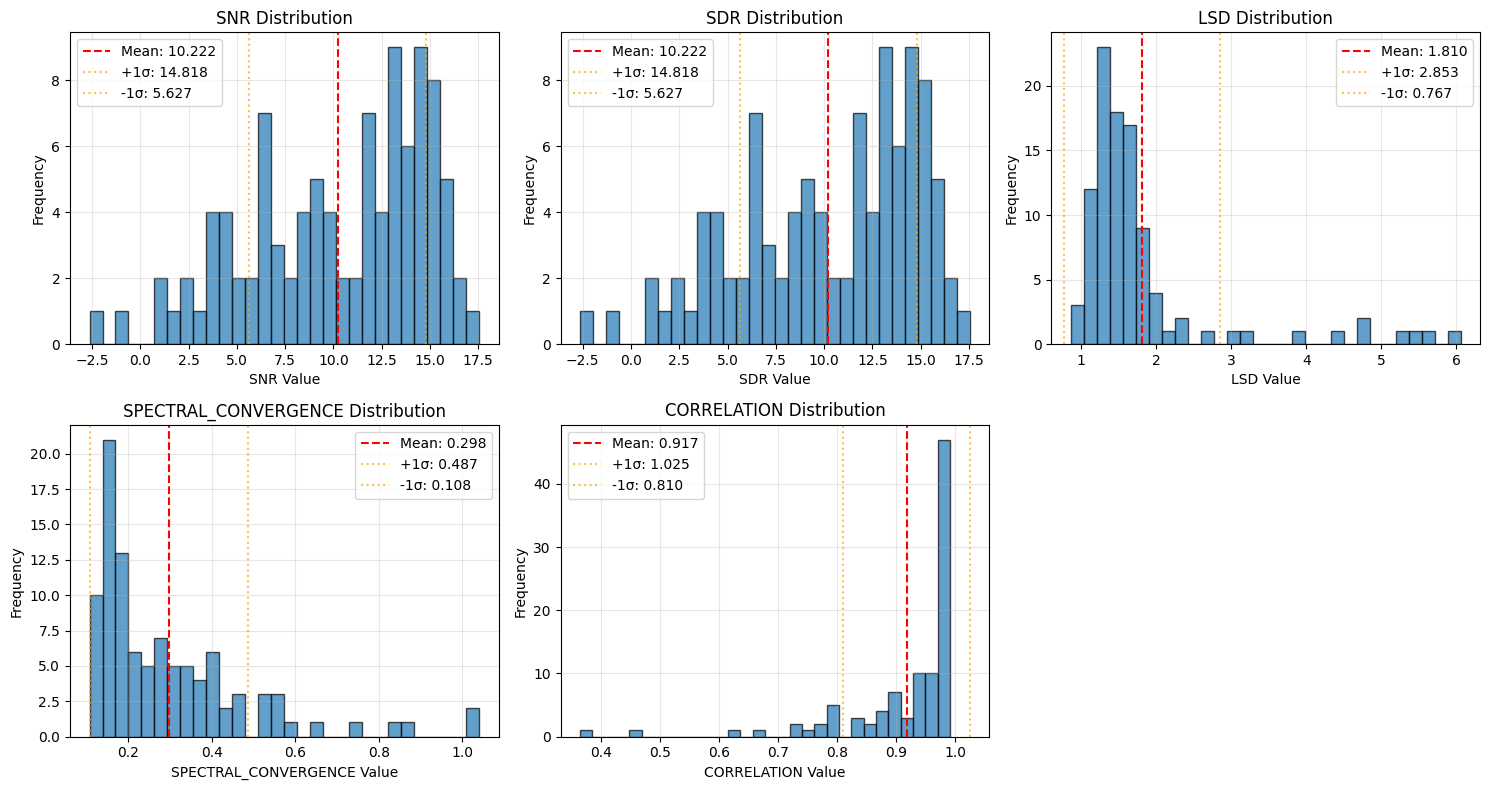


💾 Evaluation results saved to evaluation_results_final.json

🎯 Final Summary:
   📊 Audio SNR:  10.22 ± 4.60 dB
      ✅ Excellent enhancement!

✅ Evaluation complete!
📁 Audio samples in: audio_samples_final/
🎧 Listen to the samples above to assess quality


In [22]:
# Main execution - WORKING VERSION
if __name__ == "__main__":
    print("🧪 Speech Enhancement Evaluation Pipeline")
    
    # Configuration
    config = {
        'model_checkpoint': '/kaggle/input/unet-logmel-checkpoints/pytorch/default/1/checkpoints/unet_logmel/best_model.pth',
        'feature_dir': '/kaggle/input/voicebank-features/voicebank_features',
        'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        'sample_rate': 16000,
        'n_fft': 512,
        'hop_length': 128,
        'n_mels': 64,
        'max_evaluation_samples': 100,
        'num_audio_samples': 5
    }
    
    print("\n🔧 Configuration:")
    for key, value in config.items():
        print(f"   {key}: {value}")
    
    # Check if checkpoint exists
    if not os.path.exists(config['model_checkpoint']):
        print(f"❌ Checkpoint not found: {config['model_checkpoint']}")
        exit(1)
    
    try:
        # Load normalization statistics
        print("\n📊 Loading normalization statistics...")
        stats_file = "/kaggle/input/normalisation-stats/logmel/norm_stats_logmel.pkl"
        
        if not os.path.exists(stats_file):
            print(f"❌ Stats file not found: {stats_file}")
            exit(1)
        
        import pickle
        with open(stats_file, 'rb') as f:
            stats = pickle.load(f)
        
        print(f"✅ Loaded normalization stats")
        print(f"   Noisy: μ={stats['noisy_mean']:.3f}, σ={stats['noisy_std']:.3f}")
        print(f"   Clean: μ={stats['clean_mean']:.3f}, σ={stats['clean_std']:.3f}")
        
        # Load model
        print("\n🧠 Loading trained model...")
        model = create_model('unet', in_channels=1, out_channels=1)
        checkpoint = torch.load(config['model_checkpoint'], 
                              map_location=config['device'],
                              weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(config['device'])
        model.eval()
        
        print(f"✅ Model loaded from epoch {checkpoint['epoch']}")
        print(f"   Best validation loss: {checkpoint.get('best_val_loss', 'N/A')}")
        
        # Quick sanity check
        print("\n🧪 Running sanity check...")
        quick_sanity_check(
            model=model,
            stats=stats,
            device=config['device'],
            feature_dir=config['feature_dir'],
            sr=config['sample_rate'],
            n_fft=config['n_fft'],
            hop_length=config['hop_length'],
            n_mels=config['n_mels']
        )
        
        # Generate audio samples FIRST
        print("\n🔊 Generating audio samples...")
        audio_dir = generate_audio_samples_correctly(
            model=model,
            stats=stats,
            device=config['device'],
            feature_dir=config['feature_dir'],
            output_dir='audio_samples_final',
            num_samples=config['num_audio_samples'],
            sr=config['sample_rate'],
            n_fft=config['n_fft'],
            hop_length=config['hop_length'],
            n_mels=config['n_mels']
        )
        
        # Create listening test
        print("\n🎧 Creating listening test interface...")
        create_listening_test_interface(audio_dir, num_samples=config['num_audio_samples'])
        
        # Full evaluation
        print("\n📊 Running comprehensive evaluation...")
        evaluator = ComprehensiveEvaluator(sample_rate=config['sample_rate'])
        
        metrics_summary, all_metrics = evaluate_test_set_correctly(
            model=model,
            stats=stats,
            device=config['device'],
            feature_dir=config['feature_dir'],
            evaluator=evaluator,
            max_samples=config['max_evaluation_samples'],
            sr=config['sample_rate'],
            n_fft=config['n_fft'],
            hop_length=config['hop_length'],
            n_mels=config['n_mels']
        )
        
        # Create report
        print("\n📊 Creating evaluation report...")
        report_df = create_evaluation_report(metrics_summary, 'UNet', 'Test Set')
        
        # Plot distributions
        print("\n📈 Plotting metric distributions...")
        plot_metrics_distribution(all_metrics, save_path='metrics_distribution_direct.png')
        
        # Save results
        results_file = 'evaluation_results_final.json'
        with open(results_file, 'w') as f:
            serializable_summary = {}
            for metric, stats_dict in metrics_summary.items():
                serializable_summary[metric] = {k: float(v) for k, v in stats_dict.items()}
            json.dump(serializable_summary, f, indent=2)
        
        print(f"\n💾 Evaluation results saved to {results_file}")
        
        # Final summary
        print(f"\n🎯 Final Summary:")
        print("="*60)
        
        if 'snr' in metrics_summary:
            snr_mean = metrics_summary['snr']['mean']
            snr_std = metrics_summary['snr']['std']
            print(f"   📊 Audio SNR:  {snr_mean:.2f} ± {snr_std:.2f} dB")
            
            if snr_mean > 8:
                print(f"      ✅ Excellent enhancement!")
            elif snr_mean > 5:
                print(f"      ✅ Good enhancement")
            elif snr_mean > 2:
                print(f"      ⚠️  Moderate enhancement")
            else:
                print(f"      ❌ Poor enhancement")
        
        if 'pesq' in metrics_summary and metrics_summary['pesq']['count'] > 0:
            pesq_mean = metrics_summary['pesq']['mean']
            pesq_std = metrics_summary['pesq']['std']
            print(f"   🎯 PESQ:       {pesq_mean:.3f} ± {pesq_std:.3f}")
            print(f"      (1.0=bad, 4.5=excellent)")
        
        if 'stoi' in metrics_summary and metrics_summary['stoi']['count'] > 0:
            stoi_mean = metrics_summary['stoi']['mean']
            stoi_std = metrics_summary['stoi']['std']
            print(f"   🎯 STOI:       {stoi_mean:.3f} ± {stoi_std:.3f}")
            print(f"      (0.0=unintelligible, 1.0=perfect)")
        
        print("="*60)
        print(f"\n✅ Evaluation complete!")
        print(f"📁 Audio samples in: {audio_dir}/")
        print(f"🎧 Listen to the samples above to assess quality")
        
    except Exception as e:
        print(f"❌ Evaluation failed: {e}")
        import traceback
        traceback.print_exc()
        raise